# Analiza

In [87]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie do obliczeń: {device}")

Używane urządzenie do obliczeń: cuda


In [103]:
data_dir = './Waste-Classification-1'

data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224), 
        transforms.RandomHorizontalFlip(), 
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'valid': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {
    x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
    for x in ['train', 'valid', 'test']
}

dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=32, shuffle=(x == 'train'), num_workers=2, pin_memory=True)
    for x in ['train', 'valid', 'test']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'valid', 'test']}
class_names = image_datasets['train'].classes

for split in ['train', 'valid', 'test']:
    targets = image_datasets[split].targets
    print(f"{split} ({dataset_sizes[split]}):")
    for i, name in enumerate(class_names):
        print(f"  {name}: {targets.count(i)} ({targets.count(i) / dataset_sizes[split] * 100:.1f}%)")
    print()

train (1767):
  cardboard: 275 (15.6%)
  glass: 352 (19.9%)
  metal: 284 (16.1%)
  paper: 423 (23.9%)
  plastic: 340 (19.2%)
  trash: 93 (5.3%)

valid (504):
  cardboard: 84 (16.7%)
  glass: 102 (20.2%)
  metal: 85 (16.9%)
  paper: 107 (21.2%)
  plastic: 96 (19.0%)
  trash: 30 (6.0%)

test (253):
  cardboard: 44 (17.4%)
  glass: 47 (18.6%)
  metal: 40 (15.8%)
  paper: 64 (25.3%)
  plastic: 44 (17.4%)
  trash: 14 (5.5%)



# Definiowanie Modelu

In [89]:
class NikTechTrashClassificationCnn(nn.Module):
    def __init__(self, num_classes):
        super(NikTechTrashClassificationCnn, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        
        self.dropout = nn.Dropout(0.5)
        
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        
        x = x.view(-1, 128 * 28 * 28) 
        

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

liczba_klas = len(class_names)

model = NikTechTrashClassificationCnn(num_classes=liczba_klas).to(device)

print(model)
print(f"\nModel pomyślnie załadowany na urządzenie: {device}")

NikTechTrashClassificationCnn(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=100352, out_features=512, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=6, bias=True)
)

Model pomyślnie załadowany na urządzenie: cuda


# Pętla treningowa

In [90]:
#HIPERPARAMETRY
NUM_EPOCHS = 30
LEARNING_RATE = 0.001

In [91]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.5,
)

In [92]:
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':  []
}

best_val_acc    = 0.0
best_model_path = 'best_model.pth'

In [93]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()


        running_loss += loss.item() * images.size(0)
        _, predicted  = torch.max(outputs, 1)
        running_correct += (predicted == labels).sum().item()
        total += labels.size(0)

        if (batch_idx + 1) % 10 == 0:
            print(f"  Batch [{batch_idx+1}/{len(loader)}] Loss: {loss.item():.4f}")

    epoch_loss = running_loss / total
    epoch_acc  = running_correct / total
    return epoch_loss, epoch_acc


def validate_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss    = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            running_correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = running_correct / total
    return epoch_loss, epoch_acc



In [94]:
training_start = time.time()

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print("-" * 40)

    train_loss, train_acc = train_epoch(
        model, dataloaders['train'], criterion, optimizer, device
    )

    val_loss, val_acc = validate_epoch(
        model, dataloaders['valid'], criterion, device
    )

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Trening: Loss {train_loss:.4f} | Acc: {train_acc*100:.2f}%")
    print(f"Walidacja: Loss: {val_loss:.4f}  | Acc: {val_acc*100:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch':           epoch + 1,
            'model_state':     model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'val_acc':         best_val_acc,
            'class_names':     class_names,
        }, best_model_path)
        print(f"Najlepszy model zapisany (acc: {best_val_acc*100:.2f}%)")

total_time = time.time() - training_start

print("\n" + "=" * 60)
print(f"Training skończony, najlepsza dokładnosc na zbiorze walidacyjnym: {best_val_acc*100:.2f}%")
print(f"Czas trenowania: {total_time//60:.0f}m {total_time%60:.0f}s")
print("=" * 60)


Epoch [1/30]
----------------------------------------
  Batch [10/56] Loss: 1.6984
  Batch [20/56] Loss: 1.5838
  Batch [30/56] Loss: 1.5563
  Batch [40/56] Loss: 1.6187
  Batch [50/56] Loss: 1.7292
Trening: Loss 1.7883 | Acc: 33.96%
Walidacja: Loss: 1.3176  | Acc: 49.01%
Najlepszy model zapisany (acc: 49.01%)

Epoch [2/30]
----------------------------------------
  Batch [10/56] Loss: 1.4291
  Batch [20/56] Loss: 1.3263
  Batch [30/56] Loss: 1.7442
  Batch [40/56] Loss: 1.3587
  Batch [50/56] Loss: 1.1635
Trening: Loss 1.3797 | Acc: 44.88%
Walidacja: Loss: 1.2482  | Acc: 51.98%
Najlepszy model zapisany (acc: 51.98%)

Epoch [3/30]
----------------------------------------
  Batch [10/56] Loss: 1.3416
  Batch [20/56] Loss: 1.5977
  Batch [30/56] Loss: 1.4656
  Batch [40/56] Loss: 1.3354
  Batch [50/56] Loss: 1.3565
Trening: Loss 1.3460 | Acc: 47.65%
Walidacja: Loss: 1.1546  | Acc: 52.98%
Najlepszy model zapisany (acc: 52.98%)

Epoch [4/30]
----------------------------------------
  Batc

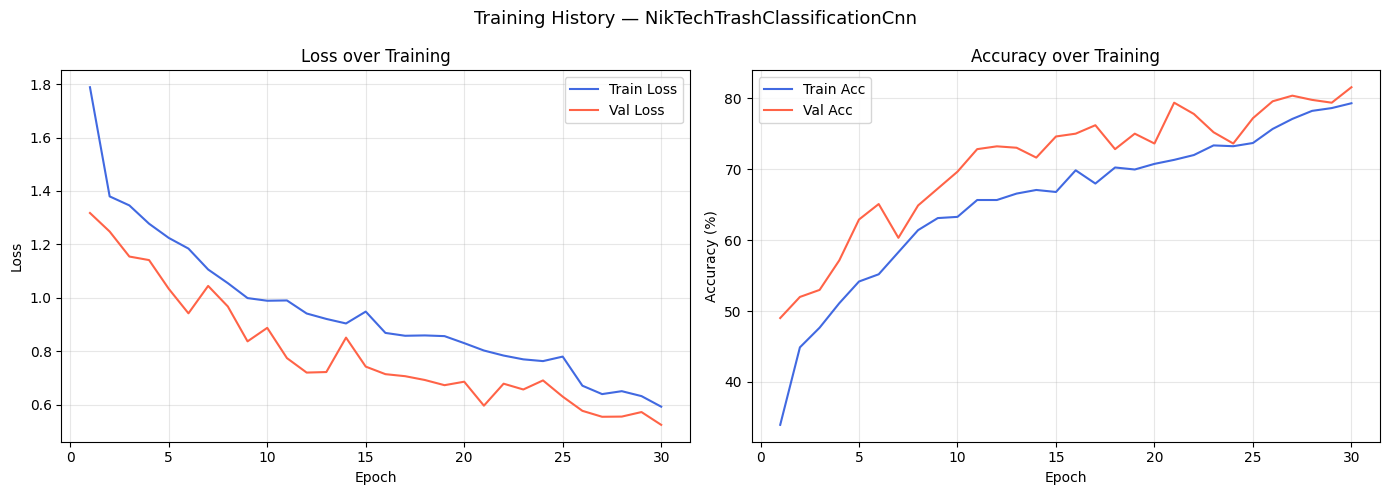

In [95]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs_range, history['train_loss'], label='Train Loss', color='royalblue')
ax1.plot(epochs_range, history['val_loss'],   label='Val Loss',   color='tomato')
ax1.set_title('Loss over Training')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs_range, [a*100 for a in history['train_acc']], label='Train Acc', color='royalblue')
ax2.plot(epochs_range, [a*100 for a in history['val_acc']],   label='Val Acc',   color='tomato')
ax2.set_title('Accuracy over Training')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Training History — NikTechTrashClassificationCnn', fontsize=13)
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

Macierz pomyłek


In [96]:
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state'])
print(f"Loaded best model from epoch {checkpoint['epoch']} (val acc: {checkpoint['val_acc']*100:.2f}%)")

model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in dataloaders['test']:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

Loaded best model from epoch 30 (val acc: 81.55%)


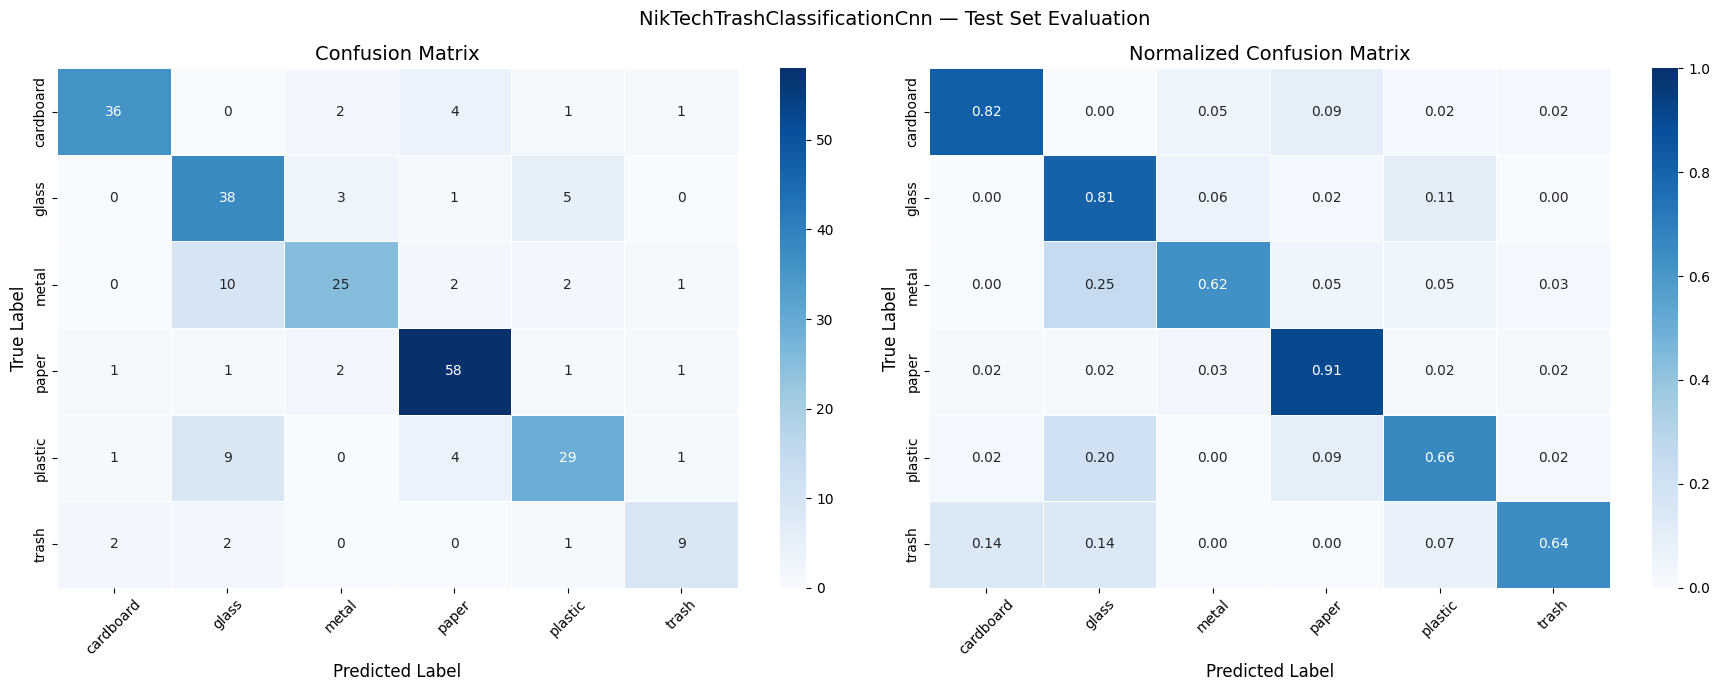

              precision    recall  f1-score   support

   cardboard     0.9000    0.8182    0.8571        44
       glass     0.6333    0.8085    0.7103        47
       metal     0.7812    0.6250    0.6944        40
       paper     0.8406    0.9062    0.8722        64
     plastic     0.7436    0.6591    0.6988        44
       trash     0.6923    0.6429    0.6667        14

    accuracy                         0.7708       253
   macro avg     0.7652    0.7433    0.7499       253
weighted avg     0.7780    0.7708    0.7699       253

Overall Test Accuracy: 77.08%


In [97]:
cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, linewidths=0.5, ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=14)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names, linewidths=0.5, vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Normalized Confusion Matrix', fontsize=14)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('NikTechTrashClassificationCnn — Test Set Evaluation', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))
print(f"Overall Test Accuracy: {(all_labels == all_preds).mean()*100:.2f}%")